<h1> Детектор объектов</h1>

In [1]:
!pip install torch torchvision torchaudio
!pip install ultralytics
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from ultralytics import YOLO
import cv2
import os

<h3>№1 Запустить YOLOv8 для распознавания объектов на изображении</h3>

In [2]:
model = YOLO('yolov8n.pt')

In [ ]:
colors = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255)
]
confi = 0.3
def process_image(image_path, new_conf=0.5, new_name='_yolo'):
    car =0
    truck = 0
    bus = 0
    image = cv2.imread(image_path)
    results = model(image)[0]
    image = results.orig_img
    classes_names = results.names
    classes = results.boxes.cls.cpu().numpy()
    boxes = results.boxes.xyxy.cpu().numpy().astype(np.int32)

    grouped_objects = {}
    for class_id, box, conf in zip(classes, boxes, results.boxes.conf):
        if conf > new_conf:
            class_name = classes_names[int(class_id)]
            color = colors[int(class_id) % len(colors)]
            
            if class_name == "truck" or "car" or "bus":
                grouped_objects[class_name] = []
            grouped_objects[class_name].append(box)
            
            if class_name == "car":
                car = car + 1
            elif class_name == "truck":
                truck = truck + 1
            elif class_name == "bus":
                bus = bus + 1

            x1, y1, x2, y2 = box
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
            cv2.putText(image, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    new_image_path = os.path.splitext(image_path)[0] + new_name + os.path.splitext(image_path)[1]
    cv2.imwrite(new_image_path, image)

    return new_image_path, car, truck, bus




0: 384x640 20 cars, 4 buss, 2 trucks, 26.7ms
Speed: 1.6ms preprocess, 26.7ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)


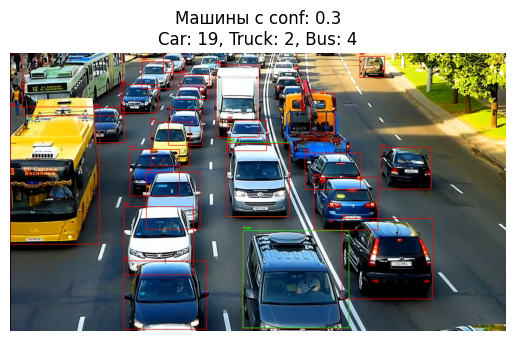

In [10]:
image_path = '2.jpg'
saved_image_path, car, truck, bus = process_image(image_path, confi)
image = cv2.imread(saved_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title(f"Машины с conf: {confi}\nCar: {car}, Truck: {truck}, Bus: {bus}")
plt.axis('off')
plt.show()

<h3>№2 Изменить порог вероятности (conf) и сравнить результаты</h3>

In [5]:
def ploti(image_path, confi = "0.3", car = 0, truck = 0, bus = 0):
    confi = round(float(confi), 2) 
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.title(f"Машины с conf: {confi}\nCar: {car}, Truck: {truck}, Bus: {bus}")
    plt.axis('off')
    plt.show()


0: 384x640 20 cars, 4 buss, 2 trucks, 28.4ms
Speed: 1.3ms preprocess, 28.4ms inference, 4.7ms postprocess per image at shape (1, 3, 384, 640)


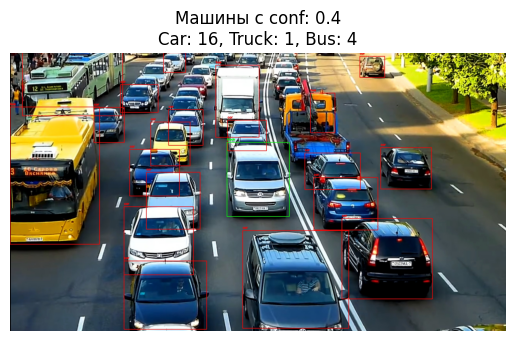


0: 384x640 20 cars, 4 buss, 2 trucks, 29.3ms
Speed: 2.7ms preprocess, 29.3ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)


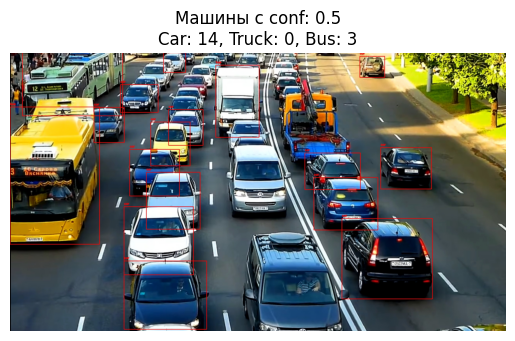


0: 384x640 20 cars, 4 buss, 2 trucks, 28.5ms
Speed: 1.4ms preprocess, 28.5ms inference, 4.6ms postprocess per image at shape (1, 3, 384, 640)


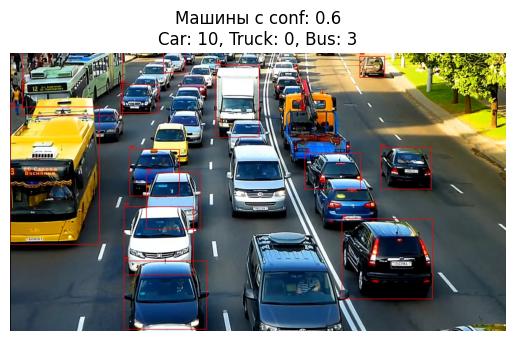


0: 384x640 20 cars, 4 buss, 2 trucks, 39.1ms
Speed: 1.3ms preprocess, 39.1ms inference, 3.9ms postprocess per image at shape (1, 3, 384, 640)


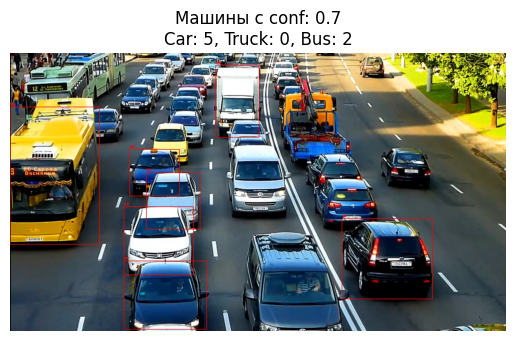


0: 384x640 20 cars, 4 buss, 2 trucks, 29.7ms
Speed: 1.2ms preprocess, 29.7ms inference, 4.7ms postprocess per image at shape (1, 3, 384, 640)


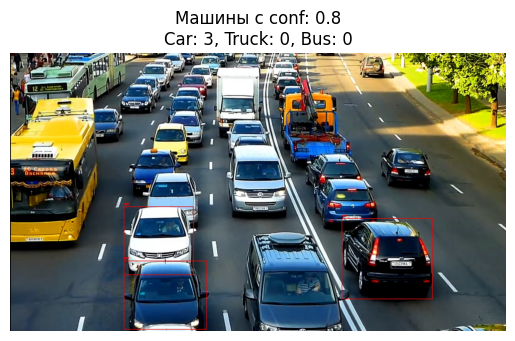

In [7]:
for i in range(5):
    new_conf = 0.3 + i * 0.1 + 0.1
    new_name = f"_yolo_{i}"
    saved_image_path, car_count, truck_count, bus_count = process_image(image_path=image_path, new_conf=round(new_conf, 2), new_name=new_name)
    ploti(saved_image_path, confi = f"{new_conf}", car=car_count, truck=truck_count, bus=bus_count)

<h3>№4 Провести детекцию объектов в коротком видео (5–10 секунд)</h3>

In [ ]:
input_video_path = 'probka_1.mp4'
capture = cv2.VideoCapture(input_video_path)
fps = int(capture.get(cv2.CAP_PROP_FPS))
width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
while True:
    ret, frame = capture.read()
    if not ret:
        break
    results = model(frame)[0]
    classes_names = results.names
    classes = results.boxes.cls.cpu().numpy()
    boxes = results.boxes.xyxy.cpu().numpy().astype(np.int32)
    for class_id, box, conf in zip(classes, boxes, results.boxes.conf):
        if conf > 0.4:
            class_name = classes_names[int(class_id)]
            if class_name in ["car", "truck", "bus"]:
                if class_name == "car":
                    color = colors[0]
                elif class_name == "truck":
                    color = colors[1]
                elif class_name == "bus":
                    color = colors[2]
                
                x1, y1, x2, y2 = box
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    cv2.imshow('Object Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

capture.release()
cv2.destroyAllWindows()

<h3>№5 Сравнить результаты YOLOv8n и YOLOv8s на одном и том же
изображении.</h3>

In [ ]:


model = YOLO('yolov8n.pt')
saved_image_path,
car_count,
truck_count, bus_count = process_image(image_path=image_path, new_conf=0.3, new_name=new_name)
ploti(saved_image_path, confi = f"{new_conf}", car=car_count, truck=truck_count, bus=bus_count)

model = YOLO('yolov8s.pt')
saved_image_path, car_count, truck_count, bus_count = process_image(image_path=image_path, new_conf=0.3, new_name=new_name)
ploti(saved_image_path, confi = f"{new_conf}", car=car_count, truck=truck_count, bus=bus_count)